In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
cd 'joined_exposure_seagrass_datasets/NSW'

/home/jovyan/dea_intertidal/dea-intertidal/notebooks/experimental/joined_exposure_seagrass_datasets/NSW


In [3]:
''' 
For NSW Gov't seagrass datasets:
Read in geojson file of the exposure raster, reduced to points(Raster Pixels to Points)
then joined by location (Join attributes by location (summary)) representing the field data
(seagrass polygons ds), generated in QGIS.
'''
ds1 = gpd.read_file('Port_hacking_exposure_join2.geojson')
ds2 = gpd.read_file('Nambucca_Macleay_exposure_join.geojson')
ds3 = gpd.read_file('Hastings_River_exposure_join.geojson')

In [4]:
ds = pd.concat([ds1,ds2,ds3])

In [5]:
ds = ds[['VALUE',
     'Macrophyte_min',
     ]]

In [6]:
ds['Macrophyte_min'].unique()

array(['Zostera', 'Posidonia', 'Posidonia/Zostera', 'Saltmarsh',
       'Mangrove'], dtype=object)

In [7]:
ds

,VALUE,Macrophyte_min
0,26.0,Zostera
1,44.0,Zostera
2,27.0,Zostera
3,26.0,Zostera
4,26.0,Zostera
...,...,...
324,53.0,Zostera
325,34.0,Zostera
326,22.0,Zostera
327,49.0,Zostera


In [8]:
values_by_macrophyte = ds.groupby('Macrophyte_min')['VALUE'].apply(list)
values_by_macrophyte

Macrophyte_min
Mangrove                                            [83.0, 57.0, 76.0]
Posidonia            [38.0, 41.0, 46.0, 54.0, 50.0, 31.0, 40.0, 40....
Posidonia/Zostera                       [36.0, 36.0, 27.0, 43.0, 32.0]
Saltmarsh                                     [95.0, 95.0, 94.0, 90.0]
Zostera              [26.0, 44.0, 27.0, 26.0, 26.0, 28.0, 28.0, 28....
Name: VALUE, dtype: object

(0.0, 100.0)

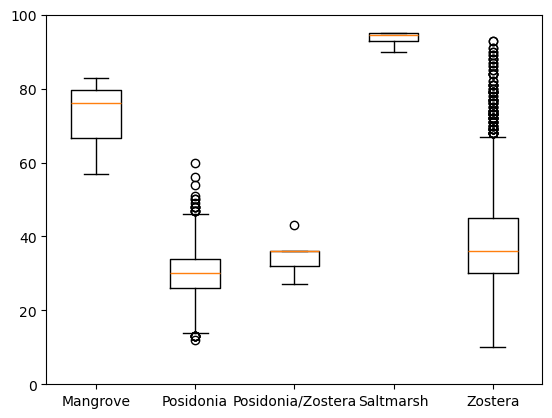

In [9]:
plt.boxplot(values_by_macrophyte, tick_labels=values_by_macrophyte.index)
plt.ylim(0,100)

Text(0.5, 1.0, 'Data density distribution (Violin) plot of exposure\n values per seagrass species with deciles (red)')

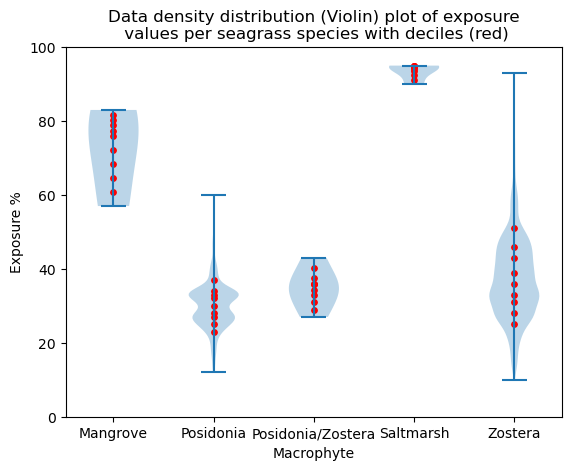

In [10]:
data = list(values_by_macrophyte)
deciles = [np.percentile(values, np.arange(10,100,10)) for values in data]

plt.violinplot(data)

for i, decile_values in enumerate(deciles, start=1):
    plt.scatter([i] * len(decile_values), decile_values, color='r', marker='o', s=15, label='Deciles' if i==1 else "")

plt.xticks(range(1,len(values_by_macrophyte) +1), values_by_macrophyte.index)
plt.ylim(0,100)

plt.xlabel("Macrophyte")
plt.ylabel("Exposure %")
plt.title("Data density distribution (Violin) plot of exposure\n values per seagrass species with deciles (red)")

In [13]:
%store values_by_macrophyte

Stored 'values_by_macrophyte' (Series)
